# epmcminer

This vignette is a hands-on guide to epmcminer, a desktop app that searches [Europe PMC](https://europepmc.org) and batch-downloads open-access PDFs into a structured local folder. It walks through all four wizard screens with step-by-step instructions and ends with a worked example showing the full output.

## The scenario

Maria is a postdoctoral researcher writing a systematic review on *neuroplasticity rehabilitation*. She needs 50 CC-BY open-access papers — fast. Downloading them one by one from PubMed would take the better part of an afternoon. With epmcminer she's done in under 10 minutes.

### What epmcminer does

epmcminer is a desktop app that searches the [Europe PubMed Central (Europe PMC)](https://europepmc.org) API, previews matching papers, and downloads their PDFs and metadata into a tidy local folder — no coding required.

### Dependencies

| Requirement | Version |
|---|---|
| Python | 3.12+ |
| PyQt6 | 6.x |
| requests | 2.x |
| pandas | 2.x |
| openpyxl | 3.x |
| reportlab | 4.x |

### Install

```bash
# either install via pip
pip install git+https://github.com/Programming-The-Next-Step-2026/epmcminer.git

# or clone the repo from github, install all dependencies and run locally in a new virtual environment
git clone https://github.com/Programming-The-Next-Step-2026/epmcminer.git
cd epmcminer
python -m venv .venv && source .venv/bin/activate
pip install -e ".[dev]"

# run the app
epmcminer
```

### Maria's workflow

1. She opens epmcminer and types `neuroplasticity AND rehabilitation` into the search box.
2. She keeps the default publication types (Review, Systematic review, etc.), leaves the licence set to **CC-BY**, and sets the date range from 2019-12-31 until today.
3. She clicks **Continue to preview**. The app queries Europe PMC and shows the top 10 results. She switches sort to **Citations** in order to get the most-cited papers first.
4. She selects the desired amount of PDFs by setting **Number of papers = 50** and picks her output folder, then clicks **Start download**.
5. The app fetches PDFs in parallel across multiple threads. A live log shows each paper's status as it completes.
6. On the Summary screen she sees 50 downloaded, 16 skipped (the reasons show "PDF unavailable"). She then exports the metadata as an Excel and the summary report as a PDF for her supervisor.

## How it fits together

The four screens map directly onto the service layer. All long-running calls — preview, download, and export — run in a parallel process (QThread) so the GUI stays responsive.

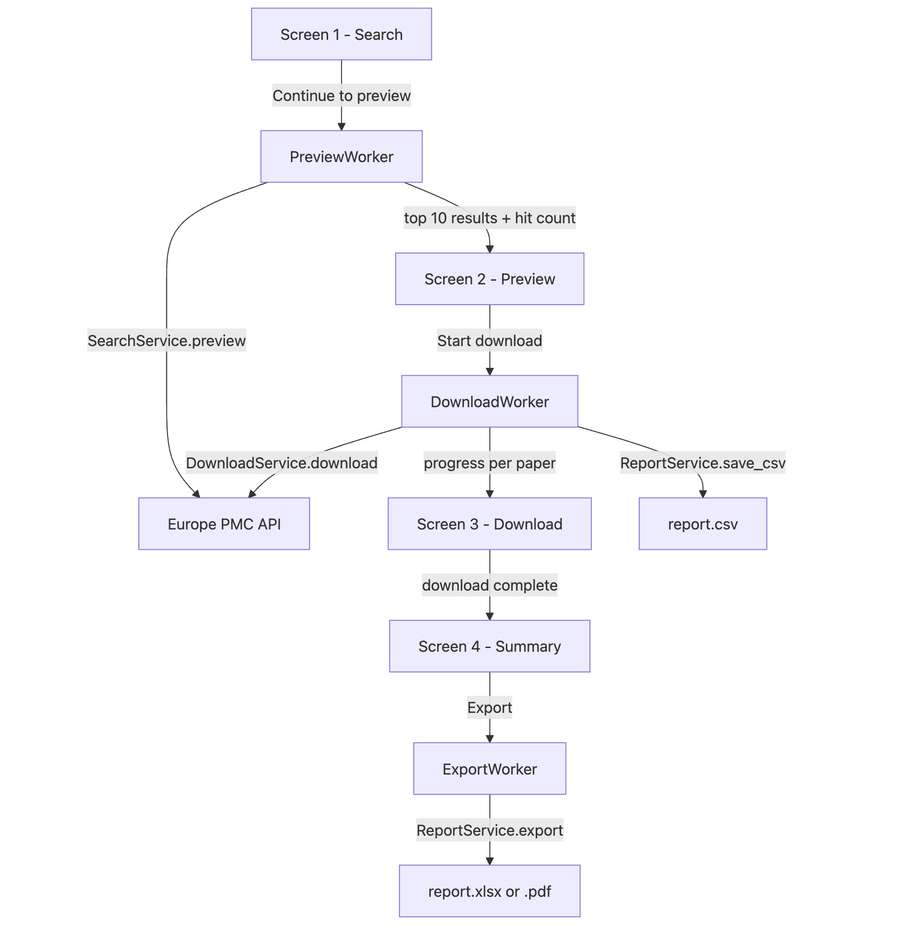

<!--

NOTE: usually a mermaid diagram would be ideal here, but the markdown rendering in Jupyter notebooks doesn't support it. The diagram is included in the source code as a comment to make future edits easy; however, I took a screenshot of the rendered diagram and included it as an image here instead to work around the github rendering issue.

```mermaid
flowchart TD
    S1[Screen 1 - Search] ->|Continue to preview| PW[PreviewWorker]
    PW ->|SearchService.preview| API[Europe PMC API]
    PW ->|top 10 results + hit count| S2[Screen 2 - Preview]
    S2 ->|Start download| DW[DownloadWorker]
    DW ->|DownloadService.download| API
    DW ->|progress per paper| S3[Screen 3 - Download]
    DW ->|ReportService.save_csv| CSV[report.csv]
    S3 ->|download complete| S4[Screen 4 - Summary]
    S4 ->|Export| EW[ExportWorker]
    EW ->|ReportService.export| OUT[report.xlsx or .pdf]
```
-->

## Screen 1 — Search

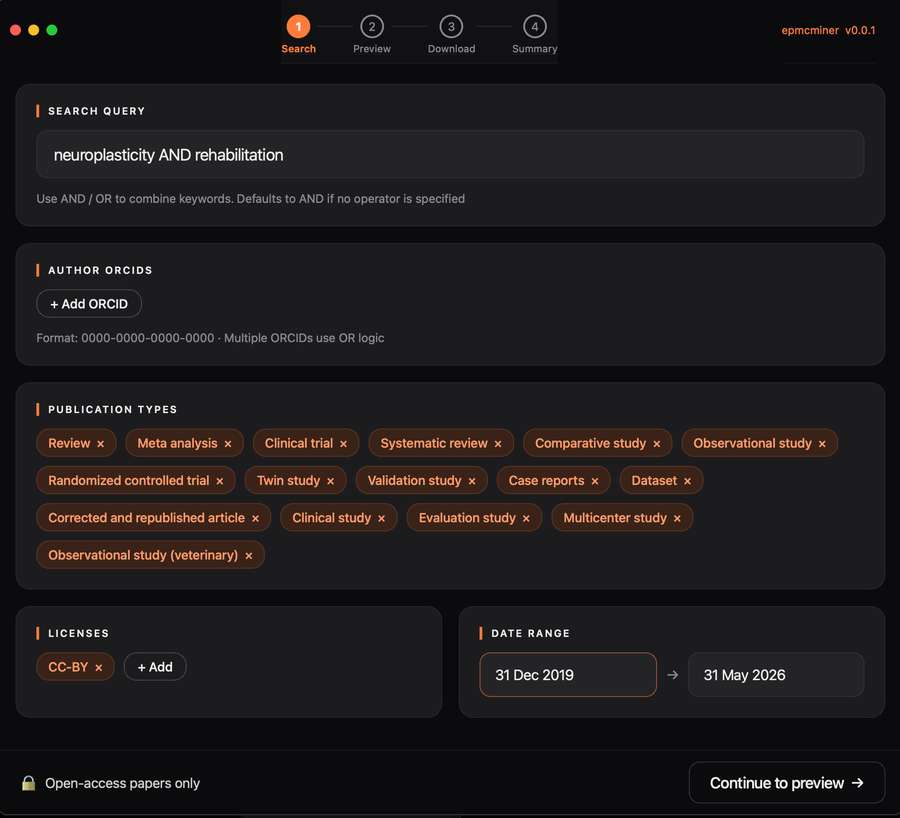

This is where you define what you're looking for.

- **Search query**: type free text — e.g. `neuroplasticity AND rehabilitation`. If you omit AND/OR operators the app inserts AND between every word automatically. The field accepts up to 500 characters.
- **Publication types**: pre-filled with 16 types (Review, Systematic review, Clinical trial, etc.). Remove any you don't need by clicking the × on a tag, or add new ones from the dropdown. At least one type must remain selected.
- **License**: defaults to CC-BY. You can add CC-BY-NC, CC0, and others from the dropdown. At least one licence must remain selected.
- **Author ORCIDs** (optional): add one or more ORCID identifiers to restrict results to specific authors. Multiple ORCIDs use OR logic. Leave empty to search all authors. Each ORCID is validated for correct format and registry existence as soon as it is added — invalid ORCIDs (red pills) are automatically excluded from the search query, while unverified ones (grey pills, shown when the network is unreachable) are still included.
- **Date range**: defaults to the past five years up to today. Click either field to open a calendar picker. The start date can go as far back as 1 January 1900. The end date is capped at today.

> The **Continue to preview** button stays disabled until the query box is non-empty, at least one publication type is selected, and at least one licence is selected. An inline hint in the action bar tells you exactly which field still needs attention.

## Screen 2 — Preview

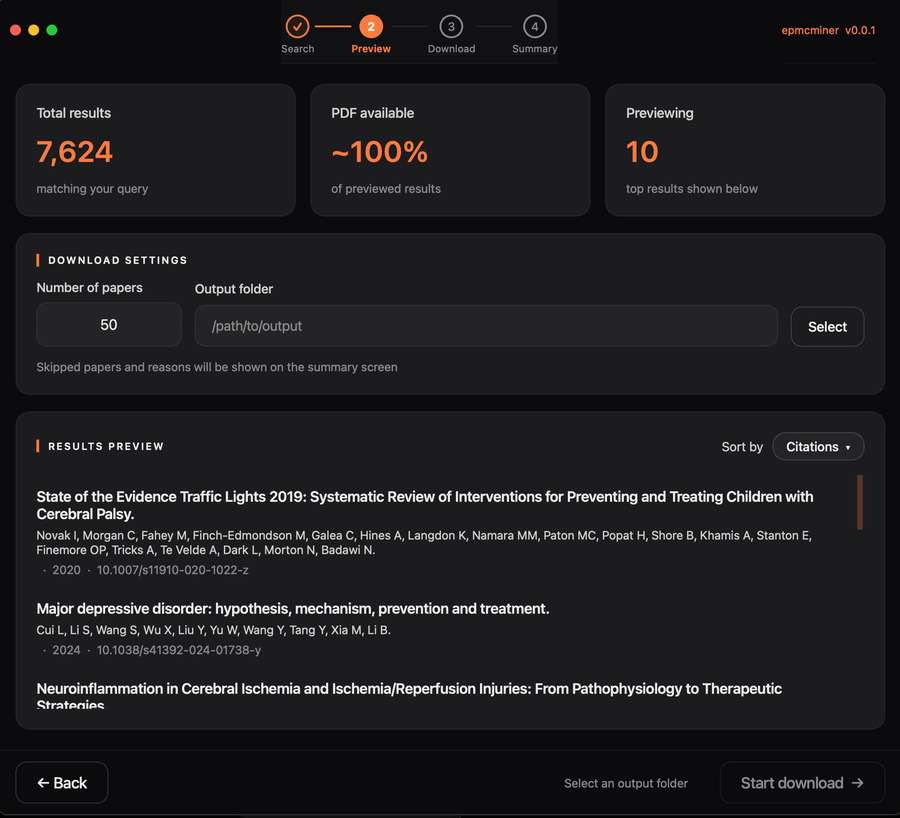

Once you click **Continue to preview**, a background thread fires off the API query. You'll see a brief loading animation, then the results land.

- **Stat cards**: three numbers across the top — *Total results* (everything matching your query in the full database), *PDF available* (percentage of previewed results that have a direct PDF link, e.g. `~62%`), and *Previewing* (the number of top results shown, up to 10).
- **Sort order**: the dropdown in the results-list header lets you switch between **Relevance** (default), **Date** (newest first), and **Citations** (most cited first). Changing it re-queries the API and refreshes the list live.
- **Download settings**: set the **Number of papers** (how many PDFs you want successfully downloaded — skipped papers don't count toward this total) and confirm the **Output folder**. The selected folder must be writable; if it isn't, the button stays disabled and the hint explains why.
- Click **← Back** at any time to return to Screen 1 with all your filters intact.

> if Total results is 0, head back and broaden the query — try fewer AND clauses, a wider date range, or extra publication types.
>
> The **Start download** button stays disabled until the number of papers is ≥ 1, an output folder is set, and the folder is writable. An inline hint in the action bar explains which condition is not yet met.

## Screen 3 — Download

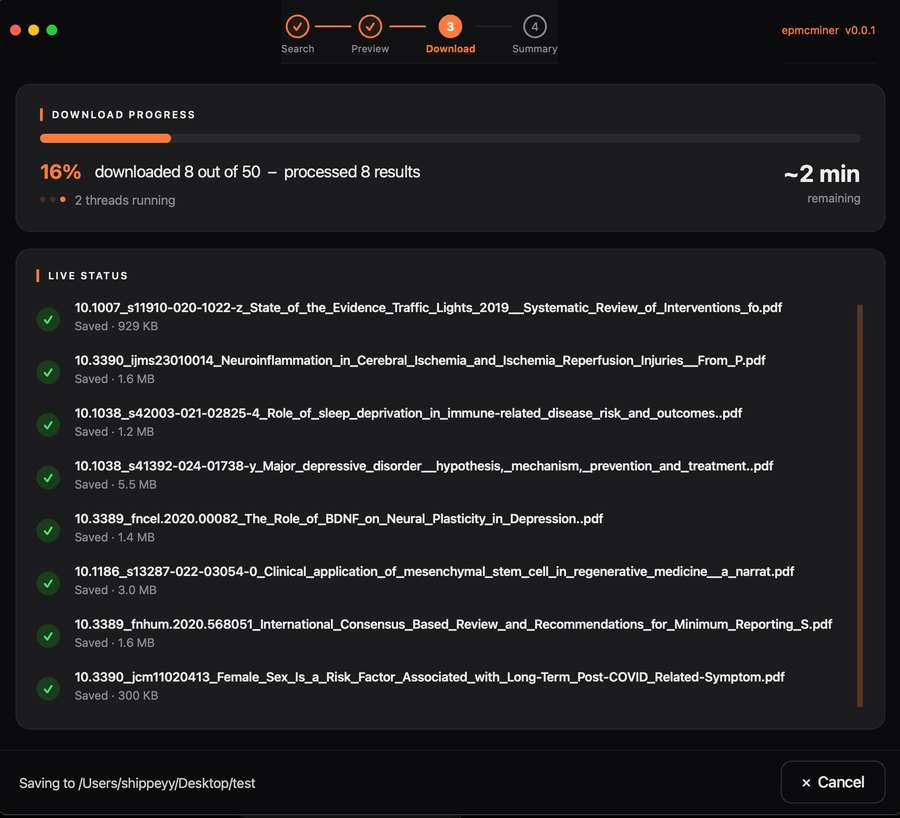

Click **Start download** and the app hands off to a background worker running multiple parallel download threads.

- **Progress bar**: shows percentage and a running tally — e.g. `46%  downloaded 23 out of 50  –  processed 31 results`, plus an estimated time remaining shown on the right (e.g. `~3 min`).
- **Live log**: every paper gets a row the moment it finishes — a green ✓ for a saved PDF, an orange – for a skip, or a red ✗ for a failure. Each row shows the filename and file size (for downloads) or the skip reason.
- **Skip reasons you'll commonly see**:
  - *PDF unavailable* — the paper is open-access but has no direct PDF link in the API response.
  - *Already downloaded* — a file with the same name already exists in your output folder. Safe to re-run into the same folder: existing papers are skipped, not duplicated.
  - *Server rate limiting* — the API is throttling your requests (HTTP 429). The app retries with exponential backoff, but if the problem persists you may have to wait a while before trying again. You can simply restart the search once it is done, as the app keeps track of which papers have already been downloaded.
  - *Connection error* — the API request failed due to a network problem. The app retries with exponential backoff, but if the problem persists check your internet connection and try again later.
- **Cancel**: click **✕ Cancel** to stop after the current batch. Already-downloaded files are kept. It might take a few moments for the cancellation to go through, as all running threads have to stop beforehand.
- `report.csv` is saved automatically to your output folder the moment the download finishes or is cancelled.

> if most papers show *PDF unavailable*, try switching sort to **Date** or **Relevance**. Highly-cited older papers are sometimes open-access in the metadata but missing a direct PDF link.

## Screen 4 — Summary

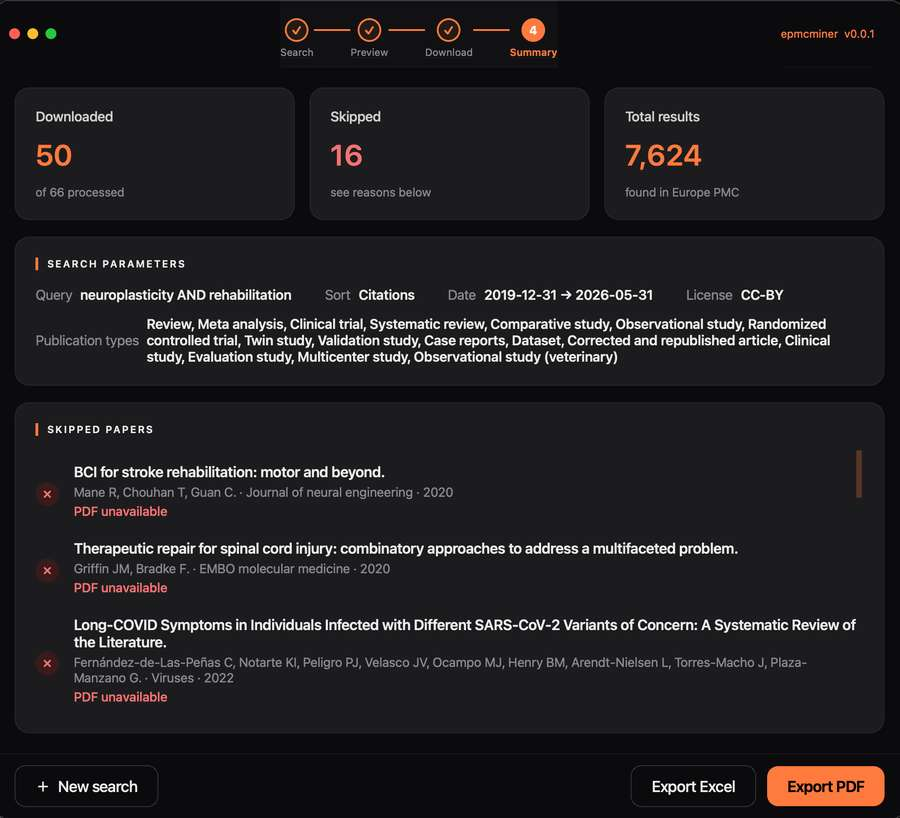

The summary screen gives you a quick debrief and lets you export the report.

- **Stat cards**: *Downloaded* (PDFs saved to disk), *Skipped* (unavailable or already downloaded), and *Total results* (the full hit count from the API).
- **Search parameters**: a compact recap of your query, sort order, and date range — handy for copying into a methods section.
- **Skipped papers**: if any papers were skipped or failed, they're listed here with title, authors, and the reason. If the skipped count is high, consider relaxing your filters or running a broader search.
- **Export Excel**: opens a save dialog and writes an `.xlsx` file — same columns as `report.csv` but with auto-formatted cells.
- **Export PDF**: opens a save dialog and writes a portrait A4 PDF that mirrors the summary screen (stat block, parameters, and skipped papers list).
- **＋ New search**: resets the wizard to Screen 1 so you can run a different query.

> exports run in the background — a toast notification confirms completion (or reports an error). Don't close the app before the toast appears, it should only take a few seconds anyways.

## Python API examples

The service and utility layers can also be called directly from Python — no GUI required. The three examples below run entirely offline (no network calls) and show the exact values the app computes internall

In [5]:
from unittest.mock import MagicMock
from epmcminer.services.search_service import SearchService
from epmcminer.api.search_params import SearchParams

# Build the Europe PMC query string from Maria's search parameters
service = SearchService(client=MagicMock())
params = SearchParams(
    query="neuroplasticity AND rehabilitation",
    date_from="2020-01-01",
    date_to="2025-05-30",
    publication_types=["Review", "Systematic review"],
    licenses=["CC-BY"],
)
print(service.build_query(params))

neuroplasticity AND rehabilitation AND (FIRST_PDATE:[2020-01-01 TO 2025-05-30]) AND (HAS_BOOK:Y OR (SRC:(MED OR PMC OR AGR OR CBA) NOT PUB_TYPE:(Review)) OR PUB_TYPE:("review") OR PUB_TYPE:("systematic review")) AND (LICENSE:"CC-BY")


In [6]:
from epmcminer.utils.file_utils import build_pdf_filename

# Show how a DOI + title are sanitised into a safe PDF filename
print(build_pdf_filename(
    "10.1111/jcpp.13842",
    "Cognitive training in children with ADHD: a systematic review",
))

10.1111_jcpp.13842_Cognitive_training_in_children_with_ADHD__a_systematic_review.pdf


In [7]:
from epmcminer.utils.orcid_utils import validate_orcid_format, normalise_orcid

# Format + ISO 7064 MOD 11-2 checksum validation — no network required
print(validate_orcid_format("0000-0001-5109-3700"))   # valid checksum → True
print(validate_orcid_format("0000-0000-0000-0000"))   # invalid checksum → False
print(normalise_orcid("https://orcid.org/0000-0001-5109-3700"))  # strip URL prefix

True
False
0000-0001-5109-3700


## Example run — "ADHD cognitive training"

Here's what a typical run looks like end to end.

**Settings used**: query `ADHD cognitive training`, licence CC-BY, publication types Review + Systematic review, sort by Citations, Count = 20, date range 2019-01-01 until 2024-12-31.

### Preview results (top 5 of the 10 shown)

| Title | Authors | Year | Journal |
|---|---|---|---|
| Cognitive training in children with ADHD: a systematic review | Cortese S et al. | 2023 | J Child Psychol Psychiatry |
| Neuroplasticity-based interventions for ADHD | Sonuga-Barke E et al. | 2022 | The Lancet Psychiatry |
| Working memory training for ADHD: an updated meta-analysis | Melby-Lervåg M et al. | 2021 | Psychological Bulletin |
| Digital cognitive training in adult ADHD | Kiani B et al. | 2023 | Frontiers in Psychiatry |
| Executive function training across the lifespan in ADHD | Willcutt E et al. | 2022 | Neurosci Biobehav Rev |

### Output folder structure

After the download finishes, the output folder looks like this:

```
~/papers/adhd_search/
├── pdfs/
│   ├── 10.1111_jcpp.13842_Cognitive_training_in_children_with_ADHD.pdf
│   ├── 10.1016_S2215-0366-22-00291-5_Neuroplasticity-based_interventions.pdf
│   ├── 10.1037_bul0000376_Working_memory_training_meta-analysis.pdf
│   ├── 10.3389_fpsyt.2023.1201447_Digital_cognitive_training_adult_ADHD.pdf
│   └── ... (13 more PDFs; 3 skipped — PDF unavailable)
├── logs/
│   └── 2024-11-14_09-22.log
└── report.csv
```

Filenames follow the pattern `{doi}_{title}.pdf` with special characters replaced by underscores. If you re-run the same search into the same folder, existing files are skipped automatically.

### report.csv (first three rows)

The report has one row per paper processed — downloads and skips alike. Key columns (the export additionally includes `authors`, `doi`, `file_path`, and the search parameters) are:

| title | journal | year | status | reason |
|---|---|---|---|---|
| Cognitive training in children with ADHD | J Child Psychol Psychiatry | 2023 | downloaded | |
| Neuroplasticity-based interventions for ADHD | The Lancet Psychiatry | 2022 | downloaded | |
| Working memory training for ADHD | Psychological Bulletin | 2021 | skipped | PDF unavailable |

The full file also includes `authors`, `doi`, `file_path`, and the search parameters (`query`, `sort_order`, `date_from`, `date_to`, `licenses`, `publication_types`).

Skipped papers have a non-empty `reason` and an empty `file_path`. Failed downloads show `PDF unavailable`, `Server rate limiting` (HTTP 429), or `Connection error` as the reason.